Bank created
Clients loaded: 7
Accounts loaded: 10
Transactions prepared: 49

=== RESULTS ===
30262c85-a34d-4d9d-afb2-3c476c6e1f9b EXECUTED | reject: None
95203e6c-bc30-405f-8ba2-2d0ddff00f73 EXECUTED | reject: None
d8dbf055-0fe9-42ac-9ff1-87d3c5697cc1 CANCELED | reject: None
daff41ab-c670-4270-9c18-85a48cc45934 EXECUTED | reject: None
32fdecf4-ba94-43a5-98bd-0b2c82331e94 EXECUTED | reject: None
67873040-53f3-4bdd-b18d-1403433e3854 EXECUTED | reject: None
1eea7e1f-ee4d-4e31-8f23-5a89dc2ace18 CANCELED | reject: None
d5236609-c3ce-4d3d-a7f6-1556115ae28b EXECUTED | reject: None
fd00117a-1d3a-4a3a-a9a2-eff9bdf1daa2 REJECTED | reject: 
9b5deaf2-badb-4522-861a-ff58297e3fd1 EXECUTED | reject: None
3907d044-4909-4d64-bc06-ef0dcb1bf38f CANCELED | reject: None
61c1bddd-672c-443d-b497-3a2075fee6f2 CANCELED | reject: None
6f0acce7-aae1-40e6-8a87-ae3200e83285 CANCELED | reject: None
83fb0514-3e05-42c2-9d41-d03b069315b0 CANCELED | reject: None
64935f9a-d2f6-44db-a499-4201f6f9c9c3 EXECUTED | reject: 

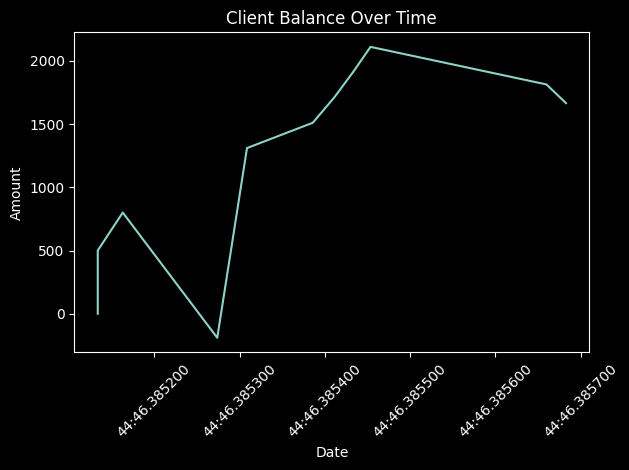

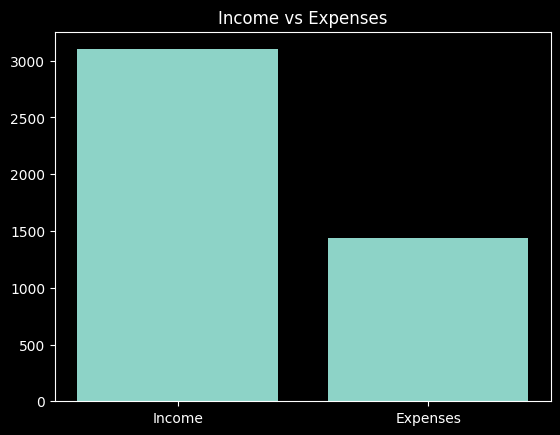

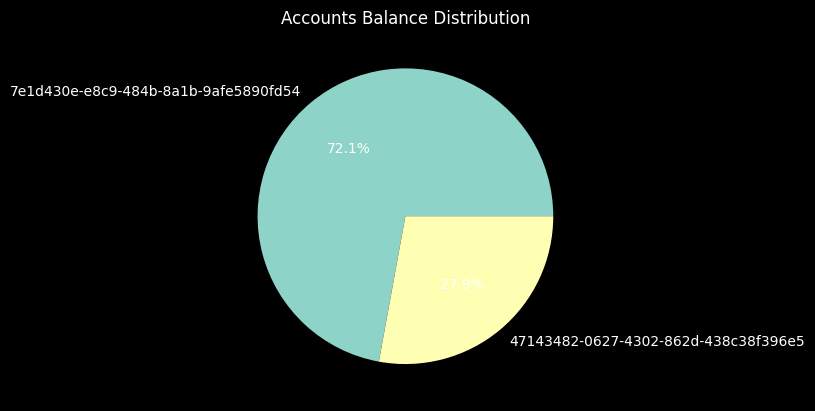

In [3]:
# ----------------------------
# Bank System — Data Driven Demo (Unified)
# ----------------------------

import sys
sys.path.append("../src")

from datetime import datetime, date, timedelta
from collections import Counter, defaultdict

from bank.bank import Bank
from bank.client import Client, Contact

from account.bank_account import BankAccount
from account.savings_account import SavingsAccount
from account.premium_account import PremiumAccount

from account.enums import AccountCurrency

from transaction.transaction import Transaction
from transaction.transaction_queue import TransactionAlreadyInQueue, QueueIsEmpty


# ----------------------------
# RAW DATA
# ----------------------------

DATA = {
    "clients": [
        {"id": "C001", "name": "Ivan Petrov", "date_of_birth": date(2000, 11, 21)},
        {"id": "C002", "name": "Anna Smirnova", "date_of_birth": date(1989, 4, 7)},
        {"id": "C003", "name": "John Smith", "date_of_birth": date(1999, 6, 13)},
        {"id": "C004", "name": "Maria Garcia", "date_of_birth": date(2001, 12, 16)},
        {"id": "C005", "name": "Liam Brown", "date_of_birth": date(2003, 3, 3)},
        {"id": "C006", "name": "Emma Wilson", "date_of_birth": date(1989, 6, 17)},
        {"id": "C007", "name": "Noah Martinez", "date_of_birth": date(2001, 1, 1)},
    ],

    "accounts": [
        {"id": "A001", "client_id": "C001", "type": "debit", "balance": 5000, "currency": "USD"},
        {"id": "A002", "client_id": "C001", "type": "savings", "balance": 2000, "currency": "EUR"},
        {"id": "A003", "client_id": "C002", "type": "debit", "balance": 8000, "currency": "USD"},
        {"id": "A004", "client_id": "C002", "type": "debit", "balance": 1500, "currency": "EUR"},
        {"id": "A005", "client_id": "C003", "type": "premium", "balance": 12000, "currency": "USD"},
        {"id": "A006", "client_id": "C004", "type": "debit", "balance": 3000, "currency": "EUR"},
        {"id": "A007", "client_id": "C004", "type": "savings", "balance": 700, "currency": "USD"},
        {"id": "A008", "client_id": "C005", "type": "debit", "balance": 4000, "currency": "USD"},
        {"id": "A009", "client_id": "C006", "type": "premium", "balance": 9500, "currency": "EUR"},
        {"id": "A010", "client_id": "C007", "type": "debit", "balance": 1000, "currency": "USD"},
    ],

    "transactions": [
        ("A001","A003",500,"USD"),
        ("A002","A006",300,"EUR"),
        ("A003","A005",7000,"USD"),
        ("A004","A006",400,"EUR"),
        ("A006","A007",500,"EUR"),
        ("A007","A008",600,"USD"),
        ("A008","A009",3500,"USD"),
        ("A009","A002",1000,"EUR"),
        ("A010","A003",200,"USD"),
        ("A002","A003",1500,"EUR"),
        ("A003","A004",9000,"USD"),
        ("A005","A001",10000,"USD"),
        ("A005","A009",11000,"USD"),
        ("A009","A003",8000,"EUR"),

        # frequent pattern
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),
        ("A001","A003",200,"USD"),

        # more normal flow
        ("A002","A004",250,"EUR"),
        ("A006","A002",300,"EUR"),
        ("A007","A001",150,"USD"),
        ("A008","A007",400,"USD"),
        ("A001","A010",350,"USD"),
        ("A003","A006",1200,"USD"),
        ("A004","A005",500,"EUR"),
        ("A005","A006",700,"USD"),

        # error cases
        ("A010","A003",999999,"USD"), # limit exceeded

        # 🔥 HIGH RISK — большие суммы
        ("A001","A003",15000,"USD"),
        ("A002","A005",18000,"EUR"),
        ("A003","A009",20000,"USD"),
        ("A005","A001",12000,"USD"),
        ("A009","A003",14000,"EUR"),

        # 🧊 ЗАМОРОЖЕННЫЙ СЧЕТ (сергей = A010)
        ("A001","A010",300,"USD"),
        ("A002","A010",700,"EUR"),
        ("A005","A010",1500,"USD"),

        # 🔥 подозрительные (разные источники → один получатель)
        ("A001","A003",3000,"USD"),
        ("A002","A003",3000,"USD"),
        ("A005","A003",3000,"USD"),

        # 🔥 очень большие + повтор
        ("A005","A003",25000,"USD"),  # limit breach
        ("A005","A003",25000,"USD"),

        # ❌ попытка использовать уже замороженный сценарий
        ("A010","A001",500,"USD"),
    ]
}


# ----------------------------
# INIT BANK
# ----------------------------

bank = Bank()
print("Bank created")


# ----------------------------
# CLIENTS
# ----------------------------

clients = {}

for c in DATA["clients"]:
    client = Client(
        name=c["name"],
        client_id=c["id"],
        date_of_birth=c["date_of_birth"],
        login=c["id"],
        password="test",
        contacts=[Contact("email", f"{c['id']}@test.com")]
    )
    bank.add_client(client)
    clients[c["id"]] = client

print(f"Clients loaded: {len(clients)}")


# ----------------------------
# ACCOUNTS
# ----------------------------

accounts = {}

def create_account(acc):
    if acc["type"] == "debit":
        return BankAccount(owner_name=clients[acc["client_id"]].name)
    elif acc["type"] == "savings":
        return SavingsAccount(owner_name=clients[acc["client_id"]].name, min_balance=100, monthly_interest=1)
    elif acc["type"] == "premium":
        return PremiumAccount(owner_name=clients[acc["client_id"]].name, fee=5)

for acc in DATA["accounts"]:
    account = create_account(acc)

    bank.open_account(acc["client_id"], account)

    # initial balance
    account.deposit(acc["balance"])

    accounts[acc["id"]] = account

print(f"Accounts loaded: {len(accounts)}")


# ----------------------------
# TRANSACTIONS
# ----------------------------

queue = bank.transaction_queue
transactions = []

for from_id, to_id, amount, currency in DATA["transactions"]:
    to_acc = accounts.get(to_id)

    if not to_acc:
        continue

    tx = Transaction(
        amount,
        AccountCurrency[currency],
        1,
        accounts[from_id],
        to_acc
    )

    transactions.append(tx)

    try:
        queue.enqueue(tx)
    except TransactionAlreadyInQueue:
        pass


# ----------------------------
# ADD SUSPICIOUS LOAD
# ----------------------------

for _ in range(6):
    queue.enqueue(
        Transaction(
            200,
            AccountCurrency.USD,
            1,
            accounts["A001"],
            accounts["A003"]
        )
    )

# freeze account scenario
bank.freeze_account(accounts["A010"].id)

print(f"Transactions prepared: {len(transactions)}")


# ----------------------------
# PROCESS
# ----------------------------

processor = bank.transaction_processor

while True:
    try:
        processor.process()
    except QueueIsEmpty:
        break


# ----------------------------
# LOGGING
# ----------------------------

print("\n=== RESULTS ===")

for t in transactions:
    print(
        t.transaction_id,
        t.status.name,
        "| reject:",
        t.reject_reason
    )


# ----------------------------
# REPORTS
# ----------------------------

print("\nSuspicious:")

for log in bank.audit_log.get_suspicious_transactions():
    print(
        getattr(log, "client_id", "-"),
        getattr(log, "risk", "-")
    )


print("\nClient risk profiles:")

for cid in clients:
    profile = bank.audit_log.get_client_risk_profile(cid)
    print(cid, dict(profile))


print("\nErrors:")

for err in bank.audit_log.get_errors():
    print(err)


# ----------------------------
# STATISTICS
# ----------------------------

print("\nStatistics:")

stats = {
    "total": len(transactions),
    "success": sum(1 for t in transactions if t.status.name == "SUCCESS"),
    "failed": sum(1 for t in transactions if t.status.name == "FAILED"),
    "rejected": sum(1 for t in transactions if t.reject_reason),
}

print(stats)


# ----------------------------
# TOTAL BALANCE
# ----------------------------

total_balance = sum(acc.balance for acc in accounts.values())

print("\nTotal balance:", total_balance)

clients_report = bank.report_builder.build_clients_report()

print(clients_report)

bank.report_builder.export_to_csv(clients_report, "clients_report.csv")

transactions_report = bank.report_builder.build_transactions_report()

print(transactions_report)

bank.report_builder.export_to_json(transactions_report, "transactions_report.json")

accounts_report = bank.report_builder.build_accounts_report()

print(accounts_report)

bank.report_builder.build_client_transactions_report("C001", "client_transactions_report.png")

bank.report_builder.build_client_income_expenses_report("C001", "client_income_expenses_report.png")

bank.report_builder.build_client_accounts_balance_report("C001", "client_accounts_balance_report.png")

